# 10 minutes to... a glacier change projection with GCM data

In this example, we illustrate how to do a typical "projection run", i.e. using GCM data. Here we will first use already bias-corrected CMIP6 data from [ISIMIP3b](https://www.isimip.org/gettingstarted/isimip3b-bias-adjustment) and than show how alternatives like the original CMIP5 and CMIP6 data can be used. 

There are three important steps:
- download the OGGM pre-processed directories containing a pre-calibrated and spun-up glacier model
- download the climate projections (and bias correct them in the case of CMIP5 or CMIP6)
- simulate the future glacier evolution from the present day state to the end of the century (2020-2100)

**Tags:** beginner, projections, CMIP, workflow 

In [1]:
# Libs
import xarray as xr
import matplotlib.pyplot as plt

# Locals
import oggm.cfg as cfg
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.shop import gcm_climate

## Pre-processed directories

Let's do a run for two Himalayan glaciers: Ngojumba and Khumbu.

In [2]:
# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')  # print less log messages than the default 

# Local working directory (where OGGM will write its output)
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_gcm_run', reset=True)

# RGI glaciers: Ngojumba and Khumbu
rgi_ids = ['RGI60-15.03473', 'RGI60-15.03733']

# Go - get the pre-processed glacier directories
# You have to explicitly indicate the url from where you want to start from
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)

2026-04-10 11:36:17: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-04-10 11:36:17: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-04-10 11:36:17: oggm.cfg: Multiprocessing: using all available processors (N=16)
2026-04-10 11:36:18: oggm.workflow: init_glacier_directories from prepro level 5 on 2 glaciers.
2026-04-10 11:36:18: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
  0% of 126.1 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
 29% of 126.1 MiB |######                | Elapsed Time: 0:00:15 ETA:   0:00:35
 49% of 126.1 MiB |##########            | Elapsed Time: 0:00:27 ETA:   0:00:27
 68% of 126.1 MiB |###############       | Elapsed Time: 0:00:42 ETA:   0:00:19
 89% of 126.1 MiB |###################   | Elapsed Time: 0:00:54 ETA:   0:00:06
100% of 126.1 MiB |######################| Elapsed Time: 0:01:02 Time:  0:01:02


## The `_spinup_historical` runs

The level 5 files now come with a pre-computed model run from the RGI outline date to the last possible date given by the historical climate data. In case of the new default climate dataset [GSWP3_W5E5](https://www.isimip.org/gettingstarted/input-data-bias-adjustment/details/80/), this is until the end of 2019, so the volume is computed until January 1st, 2020. These files are stored in the directory with a `_spinup_historical` suffix (see the ["10 minutes to... a dynamical spinup"](dynamical_spinup.ipynb) tutorial for context).

Let's compile them into a single file for our two glaciers: 

2026-04-10 11:37:40: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-10 11:37:40: oggm.utils: Applying compile_run_output on 2 gdirs.


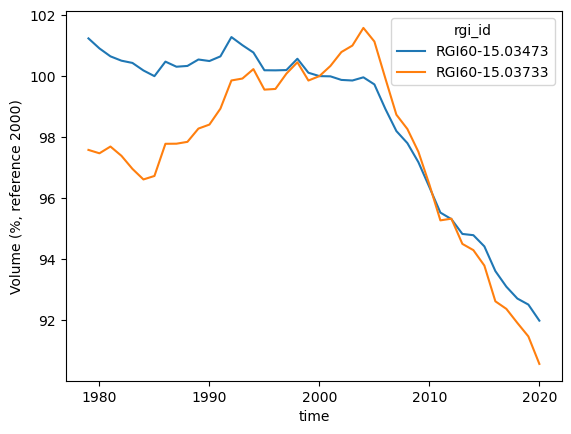

In [3]:
ds = utils.compile_run_output(gdirs, input_filesuffix='_spinup_historical')
vol_ref2000 = ds.volume / ds.volume.sel(time=2000) * 100
vol_ref2000.plot(hue='rgi_id');
plt.ylabel('Volume (%, reference 2000)');

Each RGI glacier has an "inventory date", the time at which the outline is valid:

In [4]:
gdirs[0].rgi_date, gdirs[1].rgi_date

(2000, 2002)

**The glacier volume and area estimates before that date are highly uncertain** and serve the purpose of spinup only! In the ["10 minutes to... a dynamical spinup"](dynamical_spinup.ipynb) tutorial, we talk about why. For now, these files are perfect for our purpose, since we plan to start our simulation in 2020.

## Download and process GCM data from ISIMIP3b (bias-corrected CMIP6)

A typical use case for OGGM will be to use climate model output (here bias-corrected CMIP6 GCMs from [ISIMIP3b](https://www.isimip.org/gettingstarted/isimip3b-bias-adjustment/)). We use the files [we mirrored in Bremen](https://cluster.klima.uni-bremen.de/~oggm/cmip6/isimip3b/flat/monthly/) here, but you can use whichever you want. From ISIMIP3b, we have 5 GCMs and 3 SSPs on the cluster. You can find more information on the [ISIMIP website](https://www.isimip.org/gettingstarted/isimip3b-bias-adjustment). Let's download the data:

In [5]:
# you can choose one of these 5 different GCMs:
# 'gfdl-esm4_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1' ("low sensitivity" models, within typical ranges from AR6)
# 'ipsl-cm6a-lr_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2' ("hotter" models, especially ukesm1-0-ll)
member = 'mri-esm2-0_r1i1p1f1' 

for ssp in ['ssp126', 'ssp370','ssp585']:
    # read, process and store the isimip3b data (no bias-correction done per default as already done for this setup)
    workflow.execute_entity_task(gcm_climate.process_monthly_isimip_data, gdirs, 
                                 ssp = ssp,
                                 # gcm member -> you can choose another one
                                 member=member,
                                 # recognize the climate file for later
                                 output_filesuffix=f'_ISIMIP3b_{member}_{ssp}'
                                 );

2026-04-10 11:39:13: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 2 glaciers
  0% of  18.6 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
100% of  18.6 MiB |######################| Elapsed Time: 0:00:05 Time:  0:00:05
  0% of  35.6 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
100% of  35.6 MiB |######################| Elapsed Time: 0:00:08 Time:  0:00:08
  0% of  18.6 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
100% of  18.6 MiB |######################| Elapsed Time: 0:00:04 Time:  0:00:04
  0% of  35.6 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
 97% of  35.6 MiB |##################### | Elapsed Time: 0:00:12 ETA:   0:00:00
100% of  35.6 MiB |######################| Elapsed Time: 0:00:12 Time:  0:00:12
/home/cdill/yes/envs/oggm_env/lib/python3.13/site-packages/oggm/shop/gcm_climate.py:264: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCo

The advantage of using ISIMIP3b data is that they have been bias-corrected by the ISIMIP consortium. Since we are using the [W5E5](https://docs.oggm.org/en/latest/climate-data.html#w5e5) dataset as the baseline climate in OGGM v1.6, there is no need for us to bias correct any further. If you want to bias-correct the projections yourself or want to have a larger variety of GCMs, you can also use the original CMIP5 or CMIP6 GCMs.

If you want to know which historical data you are using, you can ask OGGM:

In [6]:
gdirs[0].get_climate_info()

{'baseline_climate_source': 'GSWP3_W5E5',
 'baseline_yr_0': np.int64(1901),
 'baseline_yr_1': np.int64(2019),
 'baseline_climate_ref_hgt': np.float32(5376.0),
 'baseline_climate_ref_pix_lon': np.float64(86.75),
 'baseline_climate_ref_pix_lat': np.float64(28.25)}

## Projection runs 

We now run OGGM under various scenarios **starting from the end year of the historical spin-up run**:

In [7]:
for ssp in ['ssp126', 'ssp370', 'ssp585']:
    rid = f'_ISIMIP3b_{member}_{ssp}'
    workflow.execute_entity_task(tasks.run_from_climate_data, gdirs,
                                 climate_filename='gcm_data',  # use gcm_data, not climate_historical
                                 climate_input_filesuffix=rid,  # use the chosen scenario
                                 init_model_filesuffix='_spinup_historical',  # this is important! Start from 2020 glacier
                                 output_filesuffix=rid,  # recognize the run for later
                                );

2026-04-10 11:44:02: oggm.workflow: Execute entity tasks [run_from_climate_data] on 2 glaciers
2026-04-10 11:44:03: oggm.workflow: Execute entity tasks [run_from_climate_data] on 2 glaciers
2026-04-10 11:44:04: oggm.workflow: Execute entity tasks [run_from_climate_data] on 2 glaciers


## Plot model output 

2026-04-10 11:44:20: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-10 11:44:20: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-10 11:44:20: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-10 11:44:20: oggm.utils: Applying compile_run_output on 2 gdirs.
2026-04-10 11:44:20: oggm.utils: Applying global task compile_run_output on 2 glaciers
2026-04-10 11:44:20: oggm.utils: Applying compile_run_output on 2 gdirs.


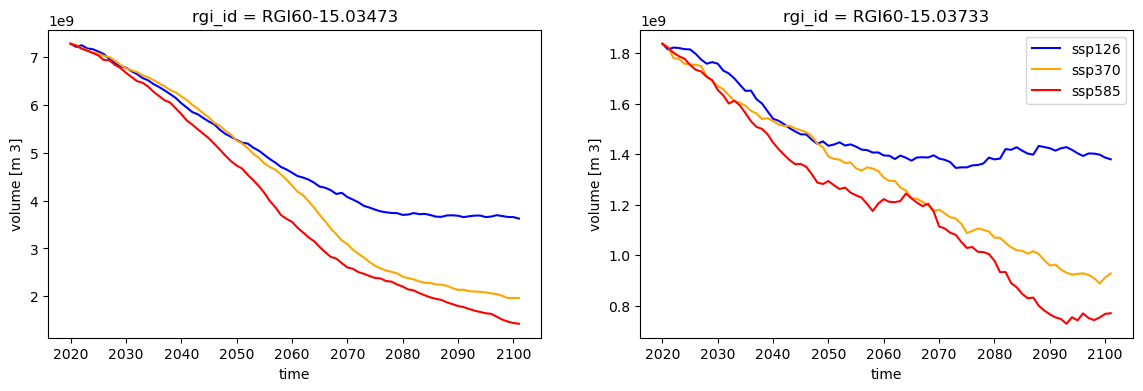

In [8]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
# Pick some colors for the lines
color_dict={'ssp126':'blue', 'ssp370':'orange', 'ssp585':'red'}
for ssp in ['ssp126','ssp370', 'ssp585']:
    rid = f'_ISIMIP3b_{member}_{ssp}'
    # Compile the output into one file
    ds = utils.compile_run_output(gdirs, input_filesuffix=rid)
    # Plot it
    ds.isel(rgi_id=0).volume.plot(ax=ax1, label=ssp, c=color_dict[ssp]);
    ds.isel(rgi_id=1).volume.plot(ax=ax2, label=ssp, c=color_dict[ssp]);
plt.legend();

**That's it! Your OGGM projection in 10 minutes.**

## Have 5 minutes more? Download and process GCM data from CMIP5 or CMIP6

ISIMIP data is very useful because it is bias corrected. Furthermore, it offers daily data (which we will soon make available in OGGM).

But you may want a higher diversity of models or scenarios: for this, you may also use the CMIP5 or CMIP6 GCMs directly. These need to be bias-corrected first to the applied baseline climate (see [process_gcm_data](https://docs.oggm.org/en/stable/generated/oggm.tasks.process_gcm_data.html#oggm.shop.gcm_climate.process_gcm_data)). This relatively simple bias-correction is automatically done by `process_cmip_data` and is very important, as the model is very sensitive to temperature variability (see the following [blogpost](https://oggm.org/2021/08/05/mean-forcing/) for more details).
- CMIP5 has 4 different RCP scenarios and a variety of GCMs, online you can find them [here](https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng). The above mentioned storage contains information about the data, [how to cite them](https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/README) and [tabular summaries](https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/all_gcm_table.html) of the available GCMs. 
- CMIP6 has 4 different SSP scenarios, see [this table](https://cluster.klima.uni-bremen.de/~oggm/cmip6/all_gcm_table.html) for a summary of available GCMs. There are even some CMIP6 runs that go until [2300](https://cluster.klima.uni-bremen.de/~oggm/cmip6/gcm_table_2300.html).

> Note, that the CMIP5 and CMIP6 files are much larger than the ISIMIP3b files. This is because we use a simple processing trick for the ISIMIP3b GCM files as we only save the glacier gridpoints, instead of the entire globe for CMIP5 and CMIP6.0 

**Therefore: run the following code only if it is ok to download a few gigabytes of data.** Set the variable below to true to run it. 

In [9]:
download_cmip5_data = False  # set to True to run the code below

In [10]:
if download_cmip5_data:

    bp = 'https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_{}_r1i1p1_g025.nc'
    bt = 'https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_{}_r1i1p1_g025.nc'

    color_dict_rcp={'rcp26':'blue', 'rcp45':'violet', 'rcp85':'red'}

    # Download and bias correct the data
    for rcp in ['rcp26', 'rcp45', 'rcp85']: # 'rcp60' would also be available
        # Download the files
        ft = utils.file_downloader(bt.format(rcp))
        fp = utils.file_downloader(bp.format(rcp))
        # bias correct them
        workflow.execute_entity_task(gcm_climate.process_cmip_data, gdirs, 
                                     filesuffix='_CMIP5_CCSM4_{}'.format(rcp),  # recognize the climate file for later
                                     fpath_temp=ft,  # temperature projections
                                     fpath_precip=fp,  # precip projections
                                     );

    # Run OGGM
    for rcp in ['rcp26', 'rcp45',  'rcp85']: #'rcp60',
        rid = '_CMIP5_CCSM4_{}'.format(rcp)
        workflow.execute_entity_task(tasks.run_from_climate_data, gdirs, ys=2020, 
                                     climate_filename='gcm_data',  # use gcm_data, not climate_historical
                                     climate_input_filesuffix=rid,  # use the chosen scenario
                                     init_model_filesuffix='_historical',  # this is important! Start from 2020 glacier
                                     output_filesuffix=rid,  # recognize the run for later
                                    );

    # Plot
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for rcp in ['rcp26', 'rcp45', 'rcp85']: #'rcp60',
        rid = '_CMIP5_CCSM4_{}'.format(rcp)
        ds = utils.compile_run_output(gdirs, input_filesuffix=rid)
        ds.isel(rgi_id=0).volume.plot(ax=ax1, label=rcp, c=color_dict_rcp[rcp]);
        ds.isel(rgi_id=1).volume.plot(ax=ax2, label=rcp, c=color_dict_rcp[rcp]);
    plt.legend();

Now, the same for CMIP6 but instead of RCPs, now SSPs and again with another GCM:

(**Attention! This may take some time ...**) Set the variable below to true to run it.

In [11]:
download_cmip6_data = True  # set to True to run the code below

  0% of 635.7 MiB |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
 10% of 635.7 MiB |##                    | Elapsed Time: 0:00:15 ETA:   0:02:08
 15% of 635.7 MiB |###                   | Elapsed Time: 0:00:27 ETA:   0:02:26
 27% of 635.7 MiB |######                | Elapsed Time: 0:00:42 ETA:   0:01:50
 41% of 635.7 MiB |#########             | Elapsed Time: 0:00:54 ETA:   0:01:18
 49% of 635.7 MiB |##########            | Elapsed Time: 0:01:09 ETA:   0:01:12
 54% of 635.7 MiB |###########           | Elapsed Time: 0:01:22 ETA:   0:01:08
 59% of 635.7 MiB |#############         | Elapsed Time: 0:01:37 ETA:   0:01:07
 63% of 635.7 MiB |##############        | Elapsed Time: 0:01:49 ETA:   0:01:02
 68% of 635.7 MiB |###############       | Elapsed Time: 0:02:04 ETA:   0:00:57
 72% of 635.7 MiB |###############       | Elapsed Time: 0:02:16 ETA:   0:00:52
 76% of 635.7 MiB |################      | Elapsed Time: 0:02:31 ETA:   0:00:47
 79% of 635.7 MiB |#################    

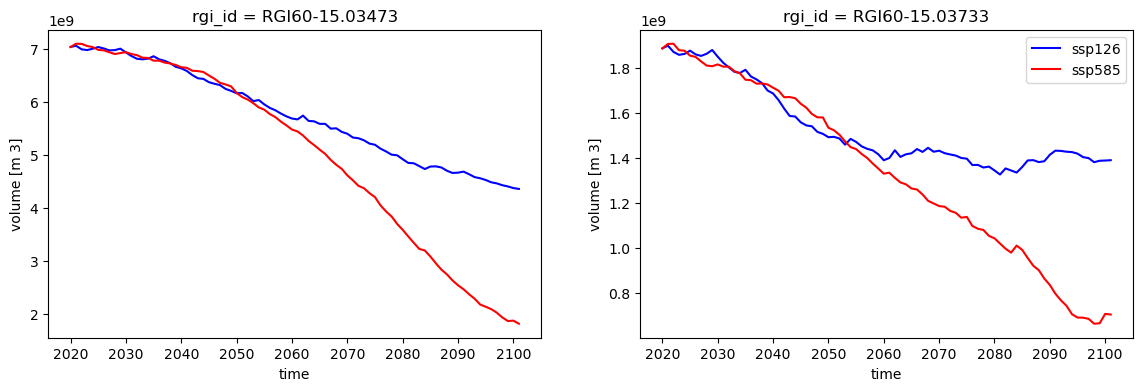

In [12]:
if download_cmip6_data:
    bp = 'https://cluster.klima.uni-bremen.de/~oggm/cmip6/GCM/CESM2/CESM2_{}_r1i1p1f1_pr.nc'
    bt = 'https://cluster.klima.uni-bremen.de/~oggm/cmip6/GCM/CESM2/CESM2_{}_r1i1p1f1_tas.nc'

    # Download and bias correct the data
    for ssp in ['ssp126', 'ssp585']:  # Removed 'ssp245', 'ssp370' because the files are large!
        # Download the files
        ft = utils.file_downloader(bt.format(ssp))
        fp = utils.file_downloader(bp.format(ssp))
        # bias correct them
        workflow.execute_entity_task(gcm_climate.process_cmip_data, gdirs, 
                                     #year_range=('1979', '2014'),
                                     filesuffix='_CMIP6_CESM2_{}'.format(ssp),  # recognize the climate file for later
                                     fpath_temp=ft,  # temperature projections
                                     fpath_precip=fp,  # precip projections
                                     );

    # Run OGGM
    for ssp in ['ssp126', 'ssp585']:
        rid = '_CMIP6_CESM2_{}'.format(ssp)
        workflow.execute_entity_task(tasks.run_from_climate_data, gdirs, ys=2020, 
                                     climate_filename='gcm_data',  # use gcm_data, not climate_historical
                                     climate_input_filesuffix=rid,  # use the chosen scenario
                                     init_model_filesuffix='_historical',  # this is important! Start from 2020 glacier
                                     output_filesuffix=rid,  # recognize the run for later
                                    );

    # Plot
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for ssp in ['ssp126', 'ssp585']:
        rid = '_CMIP6_CESM2_{}'.format(ssp)
        ds = utils.compile_run_output(gdirs, input_filesuffix=rid)
        ds.isel(rgi_id=0).volume.plot(ax=ax1, label=ssp, c=color_dict[ssp]);
        ds.isel(rgi_id=1).volume.plot(ax=ax2, label=ssp, c=color_dict[ssp]);

    plt.legend();

## What's next?

- checkout the 10 mins tutorial on the [dynamical spinup](dynamical_spinup.ipynb)
- see also the tutorial on [Merge, analyse and visualize OGGM GCM runs](../tutorials/merge_gcm_runs_and_visualize.ipynb)
- return to the [OGGM documentation](https://docs.oggm.org)
- back to the [table of contents](../welcome.ipynb)